# Gold Price Prediction using Gradient Boosting Regressor
### Predicting Tomorrow's Gold Closing Price

**Strategy:** We predict the *daily price change* (`Close_tomorrow - Close_today`) rather than the absolute price. This is critical because tree-based models cannot extrapolate beyond the training data range. We then reconstruct the absolute price by adding the predicted change to today's Close.


In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Explore Data


In [2]:
# Load the dataset
df = pd.read_csv("../../data/Gold_Market_10y.csv")

# Make sure the 'Date' column is a date format and sort the data from oldest to newest
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Print some basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Price range: ${df['Close'].min():.2f} to ${df['Close'].max():.2f}")
df.head()

Dataset shape: (2511, 16)
Date range: 2016-01-29 00:00:00 to 2026-01-23 00:00:00
Price range: $106.95 to $458.00


,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,106.949997,107.000000,106.260002,106.610001,8098700,106.949997,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,108.050003,108.150002,107.529999,107.540001,10471800,108.050003,1.028524,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,108.089996,108.180000,107.349998,107.919998,6656000,108.089996,0.037014,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,109.250000,109.580002,107.900002,107.910004,15785200,109.250000,1.073183,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,110.570000,110.699997,109.919998,110.449997,13213700,110.570000,1.208238,NaN,NaN,NaN,NaN,2016,2,3,1


In [3]:
# Find out how many missing (NaN) values are in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
Adj Close          0
Daily_Return       1
MA_20             19
MA_50             49
MA_200           199
Volatility_20     20
Year               0
Month              0
Day_of_Week        0
Quarter            0
dtype: int64


## 2. Data Cleaning



In [4]:
# Drop any rows that have missing values to clean the data
df.dropna(inplace=True)

# Reset index so the row numbers are in order again
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after dropping NaN rows: {df.shape}")
print(f"Remaining NaN values: {df.isnull().sum().sum()}")

Dataset shape after dropping NaN rows: (2312, 16)
Remaining NaN values: 0


## 3. Feature Engineering



In [5]:
# Create new features to help the model learn better

# 1. Lag features: Add columns for the closing price from 1, 2, 3, and 5 days ago
for lag in [1, 2, 3, 5]:
    df[f'Close_lag_{lag}'] = df['Close'].shift(lag)

# 2. Percentage returns: Calculate how much the price changed over 1, 2, 5, and 10 days
df['Return_1d'] = df['Close'].pct_change(1) * 100
df['Return_2d'] = df['Close'].pct_change(2) * 100
df['Return_5d'] = df['Close'].pct_change(5) * 100
df['Return_10d'] = df['Close'].pct_change(10) * 100

# 3. RSI: Calculate the Relative Strength Index (a popular trading indicator)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 4. MACD: Calculate Moving Average Convergence Divergence
ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema_12 - ema_26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist'] = df['MACD'] - df['MACD_signal']

# 5. Some extra calculations based on price and volume
bb_std = df['Close'].rolling(20).std()
df['BB_width'] = (2 * bb_std) / df['MA_20'] * 100 
df['HL_spread_pct'] = (df['High'] - df['Low']) / df['Close'] * 100 
df['OC_change_pct'] = (df['Close'] - df['Open']) / df['Open'] * 100 
df['Volume_change'] = df['Volume'].pct_change() * 100

# 6. Calculate the distance from moving averages (MA_20, MA_50, MA_200)
df['Dist_MA20_pct'] = (df['Close'] - df['MA_20']) / df['MA_20'] * 100
df['Dist_MA50_pct'] = (df['Close'] - df['MA_50']) / df['MA_50'] * 100
df['Dist_MA200_pct'] = (df['Close'] - df['MA_200']) / df['MA_200'] * 100

# Drop any rows that became missing (NaN) after all these calculations
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after feature engineering: {df.shape}")

Dataset shape after feature engineering: (2293, 35)


## 4. Create Target Variable




In [6]:
# Create the target variable we want the model to predict
# We are predicting the change in price, not the exact price
df['Price_Change'] = df['Close'].shift(-1) - df['Close']

# Save tomorrow's close price just so we can check our accuracy later
df['Tomorrow_Close'] = df['Close'].shift(-1)

# Drop the last row because we don't know tomorrow's price for it
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Final dataset shape: {df.shape}")
print(f"\nPrice change statistics:")
print(df['Price_Change'].describe())

Final dataset shape: (2292, 37)

Price change statistics:
count    2292.000000
mean        0.151147
std         2.051291
min       -25.910004
25%        -0.690002
50%         0.120010
75%         0.882504
max        15.940002
Name: Price_Change, dtype: float64


## 5. Feature Selection & Train/Test Split



In [7]:
# Group all the features we created into a list
feature_columns = [
    'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Volatility_20',
    'Year', 'Month', 'Day_of_Week', 'Quarter', 'Close_lag_1', 'Close_lag_2', 
    'Close_lag_3', 'Close_lag_5', 'Return_1d', 'Return_2d', 'Return_5d', 
    'Return_10d', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_width',
    'HL_spread_pct', 'OC_change_pct', 'Volume_change', 'Dist_MA20_pct', 
    'Dist_MA50_pct', 'Dist_MA200_pct',
]

# Provide X (features) and y (target to predict)
X = df[feature_columns]
y = df['Price_Change'] 

# Split the data chronologically (80% for training, 20% for testing)
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]  

# Keep the actual close prices for testing the final results
close_train = df['Close'][:split_index]
close_test = df['Close'][split_index:]
tomorrow_close_train = df['Tomorrow_Close'][:split_index]
tomorrow_close_test = df['Tomorrow_Close'][split_index:]

print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")


Train set: 1833 samples (80.0%)
Test set:  459 samples (20.0%)


## 6. Hyperparameter Tuning with GridSearchCV



In [8]:
# COMMIT: Apply strong regularization to prevent overfitting on noisy financial data.
# - Reduced n_estimators and max_depth to keep trees shallow and few.
# - Added max_features and min_samples_leaf constraints.
# - This forces the model to learn broad trends instead of memorizing noise.

# Set up regularized hyperparameter options for the model
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [1, 2, 3],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'subsample': [0.7, 0.8]
}

# Use TimeSeriesSplit to cross-validate the model over time
tscv = TimeSeriesSplit(n_splits=5)

# Set up the basic Gradient Boosting model
gbr = GradientBoostingRegressor(
    loss='huber',
    random_state=42,
    n_iter_no_change=20, 
    validation_fraction=0.1,
)

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f'Running GridSearchCV with {total_combos} combinations... (this may take a few minutes)')

# Use Grid Search to find the best settings from param_grid
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, 
    verbose=1,
)

# Train the grid search
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")

Running GridSearchCV with 216 combinations... (this may take a few minutes)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits



Best parameters: {'learning_rate': 0.01, 'max_depth': 1, 'max_features': 'log2', 'min_samples_leaf': 15, 'n_estimators': 50, 'subsample': 0.7}
Best CV MAE: 1.0488


## 7. Train Final Model & Make Predictions


In [9]:
# Get the best version of our model from the Grid Search
best_model = grid_search.best_estimator_

# Predict the price change for the training and testing data
pred_change_train = best_model.predict(X_train)
pred_change_test = best_model.predict(X_test)

# Calculate the final predicted price by adding the predicted change to today's close price
pred_price_train = close_train.values + pred_change_train
pred_price_test = close_test.values + pred_change_test

print("Model trained successfully!")
print(f"Number of trees used: {best_model.n_estimators_}")

Model trained successfully!
Number of trees used: 22


## 8. Model Evaluation




In [10]:
def evaluate_model(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    
    print(f"--- {label} ---")
    print(f"  MAE:   {mae:.4f}")
    print(f"  MSE:   {mse:.4f}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  R\u00b2:    {r2:.6f}")
    if mape < 1000:  # Only show MAPE if it's meaningful
        print(f"  MAPE:  {mape:.4f}%")
    print()
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print("=" * 60)
print("PRICE CHANGE PREDICTION (what the model directly predicts)")
print("=" * 60)
change_train_metrics = evaluate_model(y_train.values, pred_change_train, "Training Set - Price Change")
change_test_metrics = evaluate_model(y_test.values, pred_change_test, "Test Set - Price Change")

print("=" * 60)
print("RECONSTRUCTED ABSOLUTE PRICE (Close + predicted change)")
print("=" * 60)
price_train_metrics = evaluate_model(tomorrow_close_train.values, pred_price_train, "Training Set - Absolute Price")
price_test_metrics = evaluate_model(tomorrow_close_test.values, pred_price_test, "Test Set - Absolute Price")


PRICE CHANGE PREDICTION (what the model directly predicts)
--- Training Set - Price Change ---
  MAE:   0.9652
  MSE:   1.8754
  RMSE:  1.3695
  R²:    0.000183

--- Test Set - Price Change ---
  MAE:   2.5676
  MSE:   13.5232
  RMSE:  3.6774
  R²:    -0.016590
  MAPE:  104.0793%

RECONSTRUCTED ABSOLUTE PRICE (Close + predicted change)
--- Training Set - Absolute Price ---
  MAE:   0.9652
  MSE:   1.8754
  RMSE:  1.3695
  R²:    0.997209
  MAPE:  0.6225%

--- Test Set - Absolute Price ---
  MAE:   2.5676
  MSE:   13.5232
  RMSE:  3.6774
  R²:    0.996296
  MAPE:  0.8802%



## 9. Visualizations


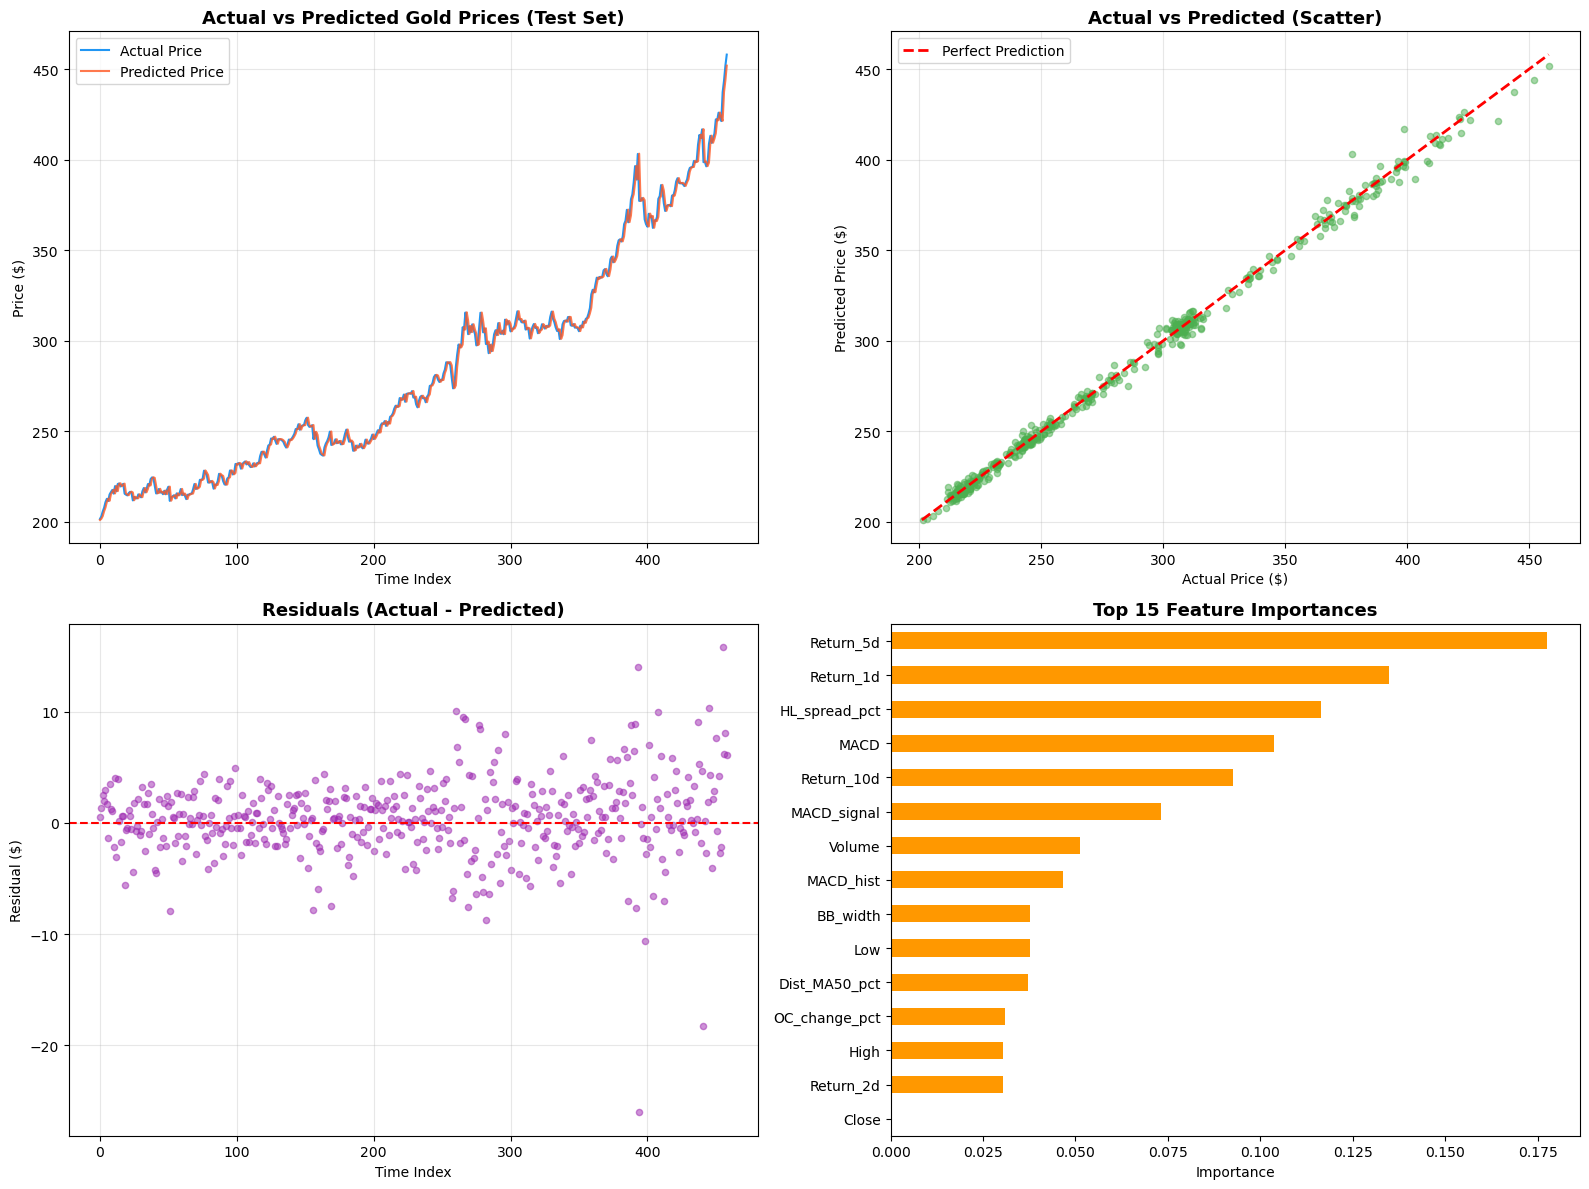

Results saved to reports/gradient_boosting_results.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted absolute prices (Test set)
ax1 = axes[0, 0]
test_dates = df['Date'][split_index:].values
ax1.plot(range(len(tomorrow_close_test)), tomorrow_close_test.values, 
         label='Actual Price', linewidth=1.5, color='#2196F3')
ax1.plot(range(len(pred_price_test)), pred_price_test, 
         label='Predicted Price', linewidth=1.5, color='#FF5722', alpha=0.8)
ax1.set_title('Actual vs Predicted Gold Prices (Test Set)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Scatter plot: Actual vs Predicted
ax2 = axes[0, 1]
ax2.scatter(tomorrow_close_test.values, pred_price_test, alpha=0.5, s=20, color='#4CAF50')
min_val = min(tomorrow_close_test.min(), pred_price_test.min())
max_val = max(tomorrow_close_test.max(), pred_price_test.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax2.set_title('Actual vs Predicted (Scatter)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Actual Price ($)')
ax2.set_ylabel('Predicted Price ($)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Residual plot
residuals = tomorrow_close_test.values - pred_price_test
ax3 = axes[1, 0]
ax3.scatter(range(len(residuals)), residuals, alpha=0.5, s=20, color='#9C27B0')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax3.set_title('Residuals (Actual - Predicted)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Time Index')
ax3.set_ylabel('Residual ($)')
ax3.grid(True, alpha=0.3)

# 4. Feature Importance (top 15)
ax4 = axes[1, 1]
feat_imp = pd.Series(best_model.feature_importances_, index=feature_columns)
feat_imp_top = feat_imp.nlargest(15)
feat_imp_top.plot(kind='barh', ax=ax4, color='#FF9800')
ax4.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax4.set_xlabel('Importance')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('../../reports/gradient_boosting_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Results saved to reports/gradient_boosting_results.png")


## 10. Predict Tomorrow's Gold Price


In [12]:
# Use the last available data point to predict tomorrow's price
last_data = X.iloc[-1:]
today_price = df['Close'].iloc[-1]

predicted_change = best_model.predict(last_data)[0]
predicted_price = today_price + predicted_change
pct_change = (predicted_change / today_price) * 100

print(f"Today's Close Price:           ${today_price:.2f}")
print(f"Predicted Daily Change:        ${predicted_change:+.2f}")
print(f"Predicted Tomorrow's Price:    ${predicted_price:.2f}")
print(f"Predicted % Change:            {pct_change:+.2f}%")


Today's Close Price:           $451.79
Predicted Daily Change:        $+0.12
Predicted Tomorrow's Price:    $451.91
Predicted % Change:            +0.03%


## 11. Model Summary


In [13]:
print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"\nModel: Gradient Boosting Regressor")
print(f"Strategy: Predict daily price change, reconstruct absolute price")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"\nTest Set Metrics (Absolute Price):")
print(f"  R\u00b2 Score:  {price_test_metrics['R2']:.6f}")
print(f"  MAE:       ${price_test_metrics['MAE']:.4f}")
print(f"  RMSE:      ${price_test_metrics['RMSE']:.4f}")
print(f"  MAPE:      {price_test_metrics['MAPE']:.4f}%")
print(f"\nTrain Set Metrics (Absolute Price):")
print(f"  R\u00b2 Score:  {price_train_metrics['R2']:.6f}")
print(f"  MAE:       ${price_train_metrics['MAE']:.4f}")
print(f"  RMSE:      ${price_train_metrics['RMSE']:.4f}")
print(f"  MAPE:      {price_train_metrics['MAPE']:.4f}%")
print("=" * 60)


MODEL PERFORMANCE SUMMARY

Model: Gradient Boosting Regressor
Strategy: Predict daily price change, reconstruct absolute price
Best Parameters: {'learning_rate': 0.01, 'max_depth': 1, 'max_features': 'log2', 'min_samples_leaf': 15, 'n_estimators': 50, 'subsample': 0.7}

Test Set Metrics (Absolute Price):
  R² Score:  0.996296
  MAE:       $2.5676
  RMSE:      $3.6774
  MAPE:      0.8802%

Train Set Metrics (Absolute Price):
  R² Score:  0.997209
  MAE:       $0.9652
  RMSE:      $1.3695
  MAPE:      0.6225%


## 8. Export Predictions and Feature Importance to CSV
Saves the test set predictions and feature importances so they can be compared with other models.

In [14]:
import os
import pandas as pd

# 1. Export Predictions
results_df = pd.DataFrame({
    'Date': df['Date'][split_index:],
    'Actual_Close': close_test.values,
    'Predicted_Close': pred_price_test
})

output_dir = '../../outputs/gradient_boosting'
os.makedirs(output_dir, exist_ok=True)

results_path = f'{output_dir}/test_predictions_gradient_boosting.csv'
results_df.to_csv(results_path, index=False)
print(f'Predictions formally exported to: {results_path}')

# 2. Export Feature Importances
# Gradient Boosting provides feature_importances_ built-in
feature_importances = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

importance_path = f'{output_dir}/feature_importance_gradient_boosting.csv'
importance_df.to_csv(importance_path, index=False)
print(f'Feature Importances exported to: {importance_path}')

Predictions formally exported to: ../../outputs/gradient_boosting/test_predictions_gradient_boosting.csv
Feature Importances exported to: ../../outputs/gradient_boosting/feature_importance_gradient_boosting.csv
